In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import random
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score,classification_report, precision_recall_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
# mount the drive
from google.colab import drive
drive.mount('/content/drive')
# Load the flight data from the CSV file
flight_df = pd.read_csv("/content/drive/MyDrive/Productionization-of-ML-Systems/Data/flights.csv")
# Load the hotel data from the CSV file
hotel_df = pd.read_csv("/content/drive/MyDrive/Productionization-of-ML-Systems/Data/hotels.csv")
# Load the users data from the CSV file
users_df = pd.read_csv("/content/drive/MyDrive/Productionization-of-ML-Systems/Data/users.csv")

Mounted at /content/drive


In [3]:
users_df.head()

,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


In [4]:
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   code     1340 non-null   int64 
 1   company  1340 non-null   object
 2   name     1340 non-null   object
 3   gender   1340 non-null   object
 4   age      1340 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 52.5+ KB


In [5]:
users_df.describe()

,code,age
count,1340.000000,1340.000000
mean,669.500000,42.742537
std,386.968991,12.869779
min,0.000000,21.000000
25%,334.750000,32.000000
50%,669.500000,42.000000
75%,1004.250000,54.000000
max,1339.000000,65.000000


In [6]:
users_df['gender'].value_counts()

,count
gender,
male,452
female,448
none,440


In [7]:
users=users_df[(users_df['gender']=='male') | (users_df['gender']=='female') ]

In [8]:
# Encoding userCode and company to numeric values
label_encoder = LabelEncoder()

users_df['company_encoded'] = label_encoder.fit_transform(users_df['company'])
users_df['gender_encoded'] = label_encoder.fit_transform(users_df['gender'])

users_df.head()

,code,company,name,gender,age,company_encoded,gender_encoded
0,0,4You,Roy Braun,male,21,0,1
1,1,4You,Joseph Holsten,male,37,0,1
2,2,4You,Wilma Mcinnis,female,48,0,0
3,3,4You,Paula Daniel,female,23,0,0
4,4,4You,Patricia Carson,female,44,0,0


In [9]:
# Initialize the SentenceTransformer model

model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [10]:
# Encode text-based columns and create embeddings

text_columns = ['name']

for column in text_columns:
    users_df[column + '_embedding'] = users_df[column].apply(lambda text: model.encode(text))

In [11]:
text_embeddings = users_df[text_columns].values.tolist()

In [12]:
n_components = 23  # Adjust the number of components as needed
pca = PCA(n_components=n_components)
text_columns = ['name']

In [13]:
# Create an empty array to store the PCA-transformed embeddings
text_embeddings_pca = np.empty((len(users_df), n_components * len(text_columns)))

for i, column in enumerate(text_columns):
    embeddings = users_df[column + '_embedding'].values.tolist()
    embeddings_pca = pca.fit_transform(embeddings)
    text_embeddings_pca[:, i * n_components:(i + 1) * n_components] = embeddings_pca

numerical_features=['code','company_encoded','age']


X_numerical = users_df[numerical_features].values

In [14]:
# Combine PCA-transformed text embeddings and numerical features
X = np.hstack((text_embeddings_pca, X_numerical))

y = users_df['gender_encoded']

In [15]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Logistic regression**

In [16]:
# Initialize a Logistic Regression Classifier

logistic_model = LogisticRegression(random_state=42)

In [17]:
# Fit the model to the training data

logistic_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [18]:
# Predict the gender of users in the test set
y_pred_logistic = logistic_model.predict(X_test)

# Print the predicted gender values
print(y_pred_logistic)


[1 0 2 0 0 0 1 1 2 0 0 1 2 0 0 1 0 0 0 0 0 1 0 1 1 1 0 0 1 0 2 2 1 0 1 2 0
 0 2 1 1 2 0 2 2 0 0 1 1 0 1 1 1 0 0 0 1 1 1 0 0 0 1 2 1 2 1 0 2 1 1 0 1 2
 0 2 0 0 2 2 1 1 1 1 1 0 0 2 1 0 1 0 1 1 1 1 2 1 1 2 0 0 0 2 0 0 2 0 2 1 0
 1 1 2 1 1 1 0 0 1 1 2 0 0 0 1 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 2 0 1 1 1 1
 1 1 0 2 0 1 0 1 1 2 1 1 0 2 1 1 1 2 0 0 1 1 1 0 1 1 1 1 2 0 1 0 2 0 1 0 1
 1 0 1 1 2 1 0 0 0 1 1 1 0 1 0 0 1 0 0 0 1 0 1 1 1 2 1 0 0 1 1 0 1 2 0 1 1
 1 0 0 1 1 0 0 0 2 0 0 0 0 0 0 0 0 1 1 2 0 0 1 0 1 1 1 1 1 1 2 0 0 1 0 0 0
 0 0 0 0 0 1 0 2 0]


In [19]:
# Calculate and print accuracy

from sklearn.metrics import accuracy_score

# Calculate accuracy score
accuracy = accuracy_score(y_test, y_pred_logistic)

# Print the accuracy
print(f"Accuracy: {accuracy:.2f}")


Accuracy: 0.61


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model on the training set
logistic_model.fit(X_train, y_train)

# Predictions on training and validation sets
y_train_pred = logistic_model.predict(X_train)
y_val_pred = logistic_model.predict(X_val)

# Calculate accuracy on training and validation sets
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

# Print the accuracies
print("Training Accuracy:", train_accuracy)
print("Validation Accuracy:", val_accuracy)

# Check if overfitting
if train_accuracy > val_accuracy:
    print("The model is overfitting.")
else:
    print("The model is not overfitting.")

Training Accuracy: 0.6361940298507462
Validation Accuracy: 0.6044776119402985
The model is overfitting.


**Decision Tree Classifier**

In [21]:
# Initialize a Random Forest Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Fit the model to the training data
dt_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred_dt = dt_classifier.predict(X_test)

# Calculate and print accuracy
accuracy = dt_classifier.score(X_test, y_test)
print("Accuracy:", accuracy)

# Generate a classification report
report = classification_report(y_test, y_pred_dt)
print("\nClassification Report:\n", report)


Accuracy: 0.3843283582089552

Classification Report:
               precision    recall  f1-score   support

           0       0.42      0.29      0.34        89
           1       0.58      0.38      0.46        94
           2       0.28      0.48      0.36        85

    accuracy                           0.38       268
   macro avg       0.43      0.39      0.39       268
weighted avg       0.43      0.38      0.39       268



In [22]:
# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model on the training set
dt_classifier.fit(X_train, y_train)

# Predictions on training and validation sets
y_train_pred = dt_classifier.predict(X_train)
y_val_pred = dt_classifier.predict(X_val)

# Calculate accuracy on training and validation sets
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

# Print the accuracies
print("Training Accuracy:", train_accuracy)
print("Validation Accuracy:", val_accuracy)

# Check if overfitting
if train_accuracy > val_accuracy:
    print("The model is overfitting.")
else:
    print("The model is not overfitting.")

Training Accuracy: 1.0
Validation Accuracy: 0.5373134328358209
The model is overfitting.


**Random Forest Classifier**

In [23]:
# Initialize a Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Fit the model to the training data
rf_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred_rf = rf_classifier.predict(X_test)

# Calculate and print accuracy
accuracy = rf_classifier.score(X_test, y_test)
print("Accuracy:", accuracy)

# Generate a classification report
report = classification_report(y_test, y_pred_rf)
print("\nClassification Report:\n", report)

Accuracy: 0.4552238805970149

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.54      0.61        89
           1       0.54      0.31      0.39        94
           2       0.31      0.53      0.39        85

    accuracy                           0.46       268
   macro avg       0.52      0.46      0.46       268
weighted avg       0.52      0.46      0.46       268



In [24]:
# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model on the training set
rf_classifier.fit(X_train, y_train)

# Predictions on training and validation sets
y_train_pred = rf_classifier.predict(X_train)
y_val_pred = rf_classifier.predict(X_val)

# Calculate accuracy on training and validation sets
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

# Print the accuracies
print("Training Accuracy:", train_accuracy)
print("Validation Accuracy:", val_accuracy)

# Check if overfitting
if train_accuracy > val_accuracy:
    print("The model is overfitting.")
else:
    print("The model is not overfitting.")

Training Accuracy: 1.0
Validation Accuracy: 0.6007462686567164
The model is overfitting.


**Gradient Boosting Classifier**

In [25]:
# Initialize a Gradient Boosting Classifier
gb_classifier = GradientBoostingClassifier(random_state=42)

# Fit the model to the training data
gb_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred_gb = gb_classifier.predict(X_test)

# Calculate and print accuracy
accuracy = gb_classifier.score(X_test, y_test)
print("Accuracy:", accuracy)

# Generate a classification report
report = classification_report(y_test, y_pred_gb)
print("\nClassification Report:\n", report)

Accuracy: 0.3208955223880597

Classification Report:
               precision    recall  f1-score   support

           0       0.36      0.06      0.10        89
           1       0.56      0.05      0.10        94
           2       0.31      0.89      0.46        85

    accuracy                           0.32       268
   macro avg       0.41      0.33      0.22       268
weighted avg       0.41      0.32      0.21       268



In [26]:
# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the model on the training set
gb_classifier.fit(X_train, y_train)

# Predictions on training and validation sets
y_train_pred = gb_classifier.predict(X_train)
y_val_pred = gb_classifier.predict(X_val)

# Calculate accuracy on training and validation sets
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

# Print the accuracies
print("Training Accuracy:", train_accuracy)
print("Validation Accuracy:", val_accuracy)

# Check if overfitting
if train_accuracy > val_accuracy:
    print("The model is overfitting.")
else:
    print("The model is not overfitting.")


Training Accuracy: 0.917910447761194
Validation Accuracy: 0.5945273631840796
The model is overfitting.


**ROC-AUC Curve**

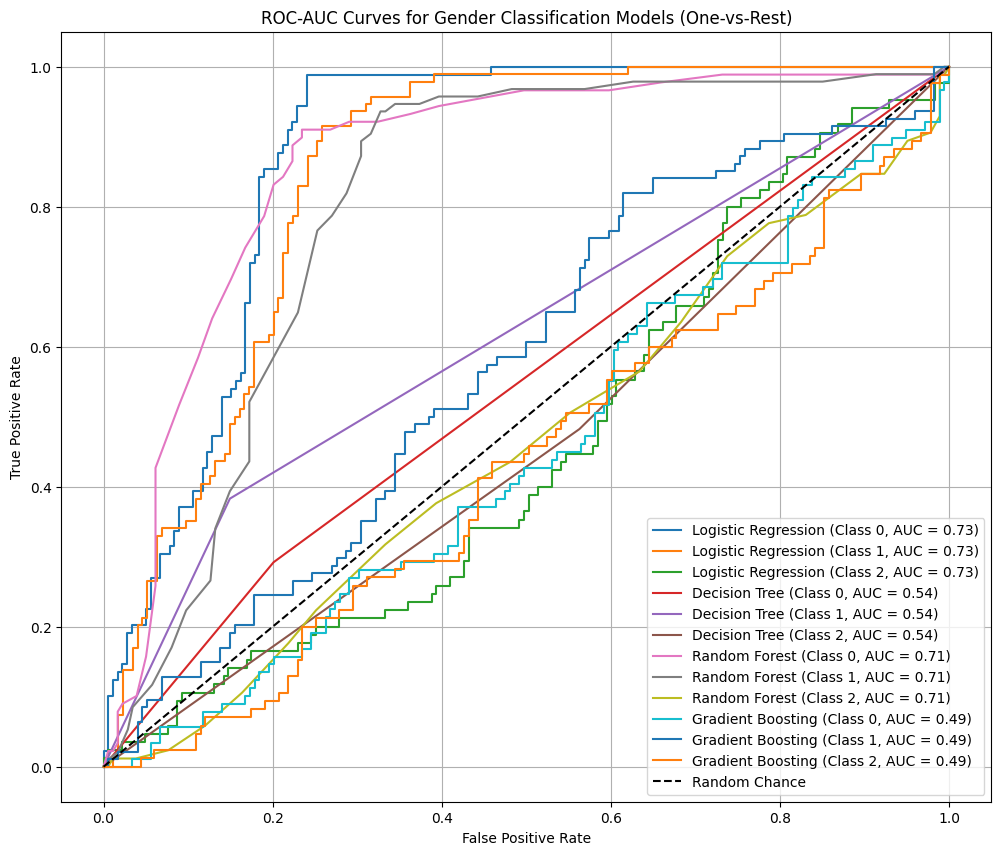

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Get the number of classes from y_test
n_classes = len(np.unique(y_test))

# Prepare to store FPR, TPR, and AUC for each model and class
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": dt_classifier,
    "Random Forest": rf_classifier,
    "Gradient Boosting": gb_classifier
}

plt.figure(figsize=(12, 10))

for name, model in models.items():
    # Get prediction probabilities for all classes
    y_prob = model.predict_proba(X_test)

    # Calculate One-vs-Rest ROC curve and AUC for each class
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test, y_prob[:, i], pos_label=i)
        auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
        plt.plot(fpr, tpr, label=f"{name} (Class {i}, AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curves for Gender Classification Models (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Model selection and Hyperparameter Tuning**

In [29]:
# Define the hyperparameter grid for Logistic Regression
param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'solver': ['liblinear', 'newton-cg', 'lbfgs', 'sag', 'saga']
}

# Perform Grid Search Cross-Validation
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(logistic_model, param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_

# Train the Logistic Regression model with the best hyperparameters
logistic_model_tuned = LogisticRegression(**best_params)
logistic_model_tuned.fit(X_train, y_train)

# Evaluate the tuned model on the test set
y_pred_tuned = logistic_model_tuned.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print("Accuracy of tuned Logistic Regression model:", accuracy_tuned)

Accuracy of tuned Logistic Regression model: 0.6343283582089553


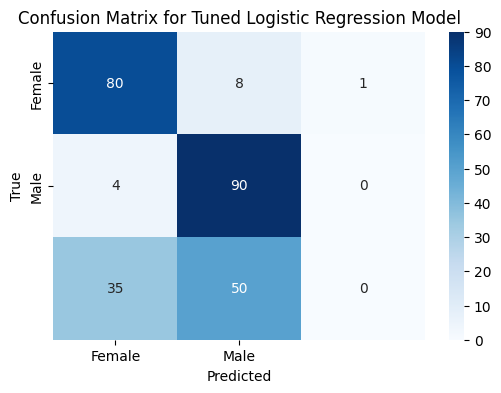

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Predict the gender of users in the test set using the tuned model
y_pred_tuned = logistic_model_tuned.predict(X_test)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned)

# Define labels for the confusion matrix
labels = ['Female', 'Male']

# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=labels, yticklabels=labels)

# Set labels and title
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Tuned Logistic Regression Model")
plt.show()


**Pickle the models**

In [32]:
import pickle

# Save the tuned Logistic Regression model
with open('/content/drive/MyDrive/Productionization-of-ML-Systems/model/logistic_model_tuned.pkl', 'wb') as f:
    pickle.dump(logistic_model_tuned, f)

# Save the scaler
with open('/content/drive/MyDrive/Productionization-of-ML-Systems/model/scaler.pkl', 'wb') as f1:
    pickle.dump(scaler, f1)

# Save the PCA model
with open('/content/drive/MyDrive/Productionization-of-ML-Systems/model/pca.pkl', 'wb') as f2:
    pickle.dump(pca, f2)